In [1]:
import time

import kagglehub

print("⏳ Downloading PaySim dataset...")
print("   This may take a few minutes depending on your connection.")

start_time = time.time()

path = kagglehub.dataset_download("ealaxi/paysim1")

elapsed = time.time() - start_time

print("✅ Download complete!")
print(f"📁 Dataset path: {path}")
print(f"⏱️ Download time: {elapsed:.1f} seconds")

⏳ Downloading PaySim dataset...
   This may take a few minutes depending on your connection.
✅ Download complete!
📁 Dataset path: /home/dawit-abraham/.cache/kagglehub/datasets/ealaxi/paysim1/versions/2
⏱️ Download time: 2.3 seconds


In [2]:
import os

import numpy as np
import pandas as pd

filename = os.listdir(path)[0]
file_path = os.path.join(path, filename)
df = pd.read_csv(file_path)

In [3]:
df.columns

Index(['step', 'type', 'amount', 'nameOrig', 'oldbalanceOrg', 'newbalanceOrig',
       'nameDest', 'oldbalanceDest', 'newbalanceDest', 'isFraud',
       'isFlaggedFraud'],
      dtype='str')

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 6362620 entries, 0 to 6362619
Data columns (total 11 columns):
 #   Column          Dtype  
---  ------          -----  
 0   step            int64  
 1   type            str    
 2   amount          float64
 3   nameOrig        str    
 4   oldbalanceOrg   float64
 5   newbalanceOrig  float64
 6   nameDest        str    
 7   oldbalanceDest  float64
 8   newbalanceDest  float64
 9   isFraud         int64  
 10  isFlaggedFraud  int64  
dtypes: float64(5), int64(3), str(3)
memory usage: 534.0 MB


In [5]:
df.isnull().sum()

step              0
type              0
amount            0
nameOrig          0
oldbalanceOrg     0
newbalanceOrig    0
nameDest          0
oldbalanceDest    0
newbalanceDest    0
isFraud           0
isFlaggedFraud    0
dtype: int64

In [6]:
df["isFraud"].value_counts()

isFraud
0    6354407
1       8213
Name: count, dtype: int64

In [7]:
df["isFraud"].value_counts(normalize=True) * 100

isFraud
0    99.870918
1     0.129082
Name: proportion, dtype: float64

In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
df.groupby("isFraud")["amount"].describe()

,count,mean,std,min,25%,50%,75%,max
isFraud,,,,,,,,
0,6354407.0,1.781970e+05,5.962370e+05,0.01,13368.395,74684.72,208364.76,92445516.64
1,8213.0,1.467967e+06,2.404253e+06,0.00,127091.330,441423.44,1517771.48,10000000.00


Amount sanity check

In [10]:
print("Zero amount:", (df["amount"] == 0).sum())
print("Negative amount:", (df["amount"] < 0).sum())
print("Minimum amount:", df["amount"].min())

Zero amount: 16
Negative amount: 0
Minimum amount: 0.0


In [11]:
zero_amount_stats = (
    df.groupby(df["amount"] == 0)["isFraud"]
    .agg(
        transactions="count",
        fraud_count="sum",
        fraud_rate="mean"
    )
)

zero_amount_stats["fraud_rate"] *= 100

zero_amount_stats

,transactions,fraud_count,fraud_rate
amount,,,
False,6362604,8197,0.128831
True,16,16,100.000000


outlier × fraud analysis

In [12]:
overall_fraud_rate = df["isFraud"].mean() * 100

print(f"Overall fraud rate: {overall_fraud_rate:.4f}%")

Overall fraud rate: 0.1291%


In [13]:
numeric_features = [
    "amount",
    "oldbalanceOrg",
    "newbalanceOrig",
    "oldbalanceDest",
    "newbalanceDest"
]



In [14]:
Q1 = df[numeric_features].quantile(0.25)
Q3 = df[numeric_features].quantile(0.75)

IQR = Q3 - Q1

outlier_mask = (
    (df[numeric_features] < (Q1 - 1.5 * IQR)) |
    (df[numeric_features] > (Q3 + 1.5 * IQR))
)

df["is_outlier"] = outlier_mask.any(axis=1)

outlier_fraud = (
    df.groupby("is_outlier")["isFraud"]
      .agg(
          transactions="count",
          fraud_count="sum",
          fraud_rate="mean"
      )
)

outlier_fraud["fraud_rate"] *= 100

outlier_fraud

,transactions,fraud_count,fraud_rate
is_outlier,,,
False,4393187,3064,0.069744
True,1969433,5149,0.261446


In [15]:
class_stats = (
    df["isFraud"]
    .value_counts()
    .rename_axis("isFraud")
    .reset_index(name="transactions")
)

class_stats["percentage"] = (
    class_stats["transactions"] / len(df) * 100
)

class_stats

,isFraud,transactions,percentage
0,0,6354407,99.870918
1,1,8213,0.129082


In [16]:
print(f"Fraud rate: {df['isFraud'].mean() * 100:.4f}%")

Fraud rate: 0.1291%


In [17]:
type_stats = (
    df.groupby("type")["isFraud"]
    .agg(
        transactions="count",
        fraud_count="sum",
        fraud_rate="mean"
    )
)

type_stats["fraud_rate"] *= 100

type_stats.sort_values("fraud_rate", ascending=False)

,transactions,fraud_count,fraud_rate
type,,,
TRANSFER,532909,4097,0.768799
CASH_OUT,2237500,4116,0.183955
CASH_IN,1399284,0,0.000000
DEBIT,41432,0,0.000000
PAYMENT,2151495,0,0.000000


In [18]:
df[df["isFraud"] == 1]["type"].value_counts()

type
CASH_OUT    4116
TRANSFER    4097
Name: count, dtype: int64

# Balance behavior

In [19]:
df["orig_balance_change"] = (
    df["oldbalanceOrg"] - df["newbalanceOrig"]
)

df["dest_balance_change"] = (
    df["newbalanceDest"] - df["oldbalanceDest"]
)

In [20]:
balance_features = [
    "amount",
    "oldbalanceOrg",
    "newbalanceOrig",
    "oldbalanceDest",
    "newbalanceDest",
    "orig_balance_change",
    "dest_balance_change"
]

balance_stats = (
    df.groupby("isFraud")[balance_features]
    .mean()
    .T
)

balance_stats.columns = ["Legitimate", "Fraud"]

balance_stats

,Legitimate,Fraud
amount,1.781970e+05,1.467967e+06
oldbalanceOrg,8.328287e+05,1.649668e+06
newbalanceOrig,8.559702e+05,1.923926e+05
oldbalanceDest,1.101421e+06,5.442496e+05
newbalanceDest,1.224926e+06,1.279708e+06
orig_balance_change,-2.314152e+04,1.457275e+06
dest_balance_change,1.235048e+05,7.354580e+05


In [21]:
df["orig_balance_error"] = (
    df["oldbalanceOrg"]
    - df["amount"]
    - df["newbalanceOrig"]
)

df["dest_balance_error"] = (
    df["oldbalanceDest"]
    + df["amount"]
    - df["newbalanceDest"]
)

In [22]:
df.groupby("isFraud")[
    ["orig_balance_error", "dest_balance_error"]
].describe()

orig_balance_error                                             \
                     count           mean            std          min   
isFraud                                                                 
0                6354407.0 -201338.558109  606928.890826 -92445516.64   
1                   8213.0  -10692.325265  265146.131130 -10000000.00   

                                                     dest_balance_error  \
               25%       50%       75%           max              count   
isFraud                                                                   
0       -249953.43 -69049.31 -3034.305  1.000000e-02          6354407.0   
1             0.00      0.00     0.000  3.725290e-09             8213.0   

                                                                             \
                  mean           std          min  25%      50%         75%   
isFraud                                                                       
0         54692.231734  4.360026e+05 -75885725.63  0.0  3500.68   29259.805   
1        732509.301069  1.867748e+06  -8875516.29  0.0  2231.46  442722.010   

                      
                 max  
isFraud               
0        13191233.98  
1        10000000.00

In [23]:
flagged_stats = (
    df.groupby("isFlaggedFraud")["isFraud"]
    .agg(
        transactions="count",
        fraud_count="sum",
        fraud_rate="mean"
    )
)

flagged_stats["fraud_rate"] *= 100

flagged_stats

,transactions,fraud_count,fraud_rate
isFlaggedFraud,,,
0,6362604,8197,0.128831
1,16,16,100.000000


In [24]:
pd.crosstab(
    df["isFlaggedFraud"],
    df["isFraud"],
    margins=True
)

isFraud,0,1,All
isFlaggedFraud,,,
0,6354407,8197,6362604
1,0,16,16
All,6354407,8213,6362620


In [25]:
numeric_features = [
    "amount",
    "oldbalanceOrg",
    "newbalanceOrig",
    "oldbalanceDest",
    "newbalanceDest",
    "orig_balance_change",
    "dest_balance_change",
    "orig_balance_error",
    "dest_balance_error"
]

In [26]:
grouped = df.groupby("isFraud")[numeric_features].agg(["mean", "std"])

mean_0 = grouped.loc[0].xs("mean", level=1)
mean_1 = grouped.loc[1].xs("mean", level=1)

std_0 = grouped.loc[0].xs("std", level=1)
std_1 = grouped.loc[1].xs("std", level=1)

smd = (
    (mean_1 - mean_0)
    / np.sqrt((std_1**2 + std_0**2) / 2)
)

feature_effects = pd.DataFrame({
    "Mean_Legitimate": mean_0,
    "Mean_Fraud": mean_1,
    "SMD": smd,
    "Abs_SMD": smd.abs()
}).sort_values("Abs_SMD", ascending=False)

feature_effects

,Mean_Legitimate,Mean_Fraud,SMD,Abs_SMD
orig_balance_change,-2.314152e+04,1.457275e+06,0.872907,0.872907
amount,1.781970e+05,1.467967e+06,0.736355,0.736355
dest_balance_error,5.469223e+04,7.325093e+05,0.499790,0.499790
dest_balance_change,1.235048e+05,7.354580e+05,0.427137,0.427137
orig_balance_error,-2.013386e+05,-1.069233e+04,0.407077,0.407077
newbalanceOrig,8.559702e+05,1.923926e+05,-0.266291,0.266291
oldbalanceOrg,8.328287e+05,1.649668e+06,0.252552,0.252552
oldbalanceDest,1.101421e+06,5.442496e+05,-0.165433,0.165433
newbalanceDest,1.224926e+06,1.279708e+06,0.014442,0.014442


In [27]:
from scipy.stats import ks_2samp

ks_results = []

for feature in numeric_features:
    legit = df.loc[df["isFraud"] == 0, feature]
    fraud = df.loc[df["isFraud"] == 1, feature]

    statistic, p_value = ks_2samp(legit, fraud)

    ks_results.append({
        "Feature": feature,
        "KS_Statistic": statistic,
        "p_value": p_value
    })

ks_results = pd.DataFrame(ks_results)

ks_results.sort_values(
    "KS_Statistic",
    ascending=False
)

,Feature,KS_Statistic,p_value
7,orig_balance_error,0.808392,0.000000e+00
5,orig_balance_change,0.804171,0.000000e+00
1,oldbalanceOrg,0.542525,0.000000e+00
0,amount,0.444136,0.000000e+00
2,newbalanceOrig,0.413745,0.000000e+00
3,oldbalanceDest,0.244726,0.000000e+00
8,dest_balance_error,0.228860,0.000000e+00
6,dest_balance_change,0.191670,2.239402e-264
4,newbalanceDest,0.115234,2.445360e-95


In [28]:
corr_matrix = df[numeric_features + ["isFraud"]].corr()

target_corr = (
    corr_matrix["isFraud"]
    .drop("isFraud")
    .sort_values(key=abs, ascending=False)
)

target_corr

orig_balance_change    0.362472
amount                 0.076688
dest_balance_error     0.055120
dest_balance_change    0.027028
orig_balance_error     0.011283
oldbalanceOrg          0.010154
newbalanceOrig        -0.008148
oldbalanceDest        -0.005885
newbalanceDest         0.000535
Name: isFraud, dtype: float64

In [29]:
feature_corr = df[numeric_features].corr()

feature_corr

,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,orig_balance_change,dest_balance_change,orig_balance_error,dest_balance_error
amount,1.000000,-0.002762,-0.007861,0.294137,0.459304,0.102337,0.845964,-0.970660,-0.189928
oldbalanceOrg,-0.002762,1.000000,0.998803,0.066243,0.042029,-0.220297,-0.087032,-0.050502,0.156464
newbalanceOrig,-0.007861,0.998803,1.000000,0.067812,0.041837,-0.267750,-0.094456,-0.056897,0.163161
oldbalanceDest,0.294137,0.066243,0.067812,1.000000,0.976569,-0.047460,0.232316,-0.304256,-0.025460
newbalanceDest,0.459304,0.042029,0.041837,0.976569,1.000000,-0.006451,0.436191,-0.458750,-0.174942
orig_balance_change,0.102337,-0.220297,-0.267750,-0.047460,-0.006451,1.000000,0.169292,0.139860,-0.171737
dest_balance_change,0.845964,-0.087032,-0.094456,0.232316,0.436191,0.169292,1.000000,-0.801148,-0.684207
orig_balance_error,-0.970660,-0.050502,-0.056897,-0.304256,-0.458750,0.139860,-0.801148,1.000000,0.147540
dest_balance_error,-0.189928,0.156464,0.163161,-0.025460,-0.174942,-0.171737,-0.684207,0.147540,1.000000


In [30]:
df[numeric_features].skew().sort_values(ascending=False)

dest_balance_change    32.916341
amount                 30.993949
orig_balance_change    24.630520
oldbalanceDest         19.921758
newbalanceDest         19.352302
oldbalanceOrg           5.249136
newbalanceOrig          5.176884
orig_balance_error    -30.074746
dest_balance_error    -49.202276
dtype: float64

In [31]:
fraud_by_step = (
    df.groupby("step")["isFraud"]
    .agg(
        transactions="count",
        fraud_count="sum",
        fraud_rate="mean"
    )
)

fraud_by_step["fraud_rate"] *= 100

fraud_by_step.head()

,transactions,fraud_count,fraud_rate
step,,,
1,2708,16,0.590842
2,1014,8,0.788955
3,552,4,0.724638
4,565,10,1.769912
5,665,6,0.902256


In [32]:
fraud_by_step.sort_values(
    "fraud_rate",
    ascending=False
).head(20)

,transactions,fraud_count,fraud_rate
step,,,
727,12,12,100.0
743,8,8,100.0
742,14,14,100.0
410,20,20,100.0
411,16,16,100.0
412,8,8,100.0
414,16,16,100.0
415,16,16,100.0
417,6,6,100.0


In [33]:
df["orig_transaction_count"] = (
    df.groupby("nameOrig")["nameOrig"]
    .transform("count")
)

df["orig_total_amount"] = (
    df.groupby("nameOrig")["amount"]
    .transform("sum")
)

df["orig_avg_amount"] = (
    df.groupby("nameOrig")["amount"]
    .transform("mean")
)

In [34]:
df["dest_transaction_count"] = (
    df.groupby("nameDest")["nameDest"]
    .transform("count")
)

df["dest_total_amount"] = (
    df.groupby("nameDest")["amount"]
    .transform("sum")
)

df["dest_avg_amount"] = (
    df.groupby("nameDest")["amount"]
    .transform("mean")
)

In [35]:
account_features = [
    "orig_transaction_count",
    "orig_total_amount",
    "orig_avg_amount",
    "dest_transaction_count",
    "dest_total_amount",
    "dest_avg_amount"
]

account_behavior = (
    df.groupby("isFraud")[account_features]
    .mean()
    .T
)

account_behavior.columns = [
    "Legitimate",
    "Fraud"
]

account_behavior

,Legitimate,Fraud
orig_transaction_count,1.002932e+00,1.003409e+00
orig_total_amount,1.787340e+05,1.468447e+06
orig_avg_amount,1.781991e+05,1.466394e+06
dest_transaction_count,1.119624e+01,8.095337e+00
dest_total_amount,3.198327e+06,3.556984e+06
dest_avg_amount,1.790205e+05,8.308296e+05


In [36]:
df["hour_of_day"] = df["step"] % 24
type_time = (
    df.groupby(["hour_of_day", "type"])["isFraud"]
    .agg(
        transactions="count",
        fraud_count="sum",
        fraud_rate="mean"
    )
    .reset_index()
)

type_time["fraud_rate"] *= 100

type_time

,hour_of_day,type,transactions,fraud_count,fraud_rate
0,0,CASH_IN,11170,0,0.000000
1,0,CASH_OUT,11997,150,1.250313
2,0,DEBIT,1647,0,0.000000
3,0,PAYMENT,40556,0,0.000000
4,0,TRANSFER,6217,150,2.412739
...,...,...,...,...,...
115,23,CASH_IN,23805,0,0.000000
116,23,CASH_OUT,26168,161,0.615255
117,23,DEBIT,2073,0,0.000000
118,23,PAYMENT,77345,0,0.000000


# SMD

In [37]:
grouped = df.groupby("isFraud")[numeric_features].agg(["mean", "std"])

mean_0 = grouped.loc[0].xs("mean", level=1)
mean_1 = grouped.loc[1].xs("mean", level=1)

std_0 = grouped.loc[0].xs("std", level=1)
std_1 = grouped.loc[1].xs("std", level=1)

smd = (
    (mean_1 - mean_0)
    / np.sqrt((std_1**2 + std_0**2) / 2)
)

feature_separation = pd.DataFrame({
    "Legitimate_Mean": mean_0,
    "Fraud_Mean": mean_1,
    "SMD": smd,
    "Abs_SMD": smd.abs()
}).sort_values("Abs_SMD", ascending=False)

feature_separation

,Legitimate_Mean,Fraud_Mean,SMD,Abs_SMD
orig_balance_change,-2.314152e+04,1.457275e+06,0.872907,0.872907
amount,1.781970e+05,1.467967e+06,0.736355,0.736355
dest_balance_error,5.469223e+04,7.325093e+05,0.499790,0.499790
dest_balance_change,1.235048e+05,7.354580e+05,0.427137,0.427137
orig_balance_error,-2.013386e+05,-1.069233e+04,0.407077,0.407077
newbalanceOrig,8.559702e+05,1.923926e+05,-0.266291,0.266291
oldbalanceOrg,8.328287e+05,1.649668e+06,0.252552,0.252552
oldbalanceDest,1.101421e+06,5.442496e+05,-0.165433,0.165433
newbalanceDest,1.224926e+06,1.279708e+06,0.014442,0.014442


# KS test

In [38]:
from scipy.stats import ks_2samp

ks_results = []

for feature in numeric_features:
    legitimate = df.loc[df["isFraud"] == 0, feature]
    fraud = df.loc[df["isFraud"] == 1, feature]

    statistic, p_value = ks_2samp(legitimate, fraud)

    ks_results.append({
        "Feature": feature,
        "KS_Statistic": statistic,
        "p_value": p_value
    })

ks_results = (
    pd.DataFrame(ks_results)
    .sort_values("KS_Statistic", ascending=False)
)

ks_results

,Feature,KS_Statistic,p_value
7,orig_balance_error,0.808392,0.000000e+00
5,orig_balance_change,0.804171,0.000000e+00
1,oldbalanceOrg,0.542525,0.000000e+00
0,amount,0.444136,0.000000e+00
2,newbalanceOrig,0.413745,0.000000e+00
3,oldbalanceDest,0.244726,0.000000e+00
8,dest_balance_error,0.228860,0.000000e+00
6,dest_balance_change,0.191670,2.239402e-264
4,newbalanceDest,0.115234,2.445360e-95


# Correlation

In [39]:
correlation = (
    df[numeric_features + ["isFraud"]]
    .corr()["isFraud"]
    .drop("isFraud")
    .sort_values(key=abs, ascending=False)
)

correlation

orig_balance_change    0.362472
amount                 0.076688
dest_balance_error     0.055120
dest_balance_change    0.027028
orig_balance_error     0.011283
oldbalanceOrg          0.010154
newbalanceOrig        -0.008148
oldbalanceDest        -0.005885
newbalanceDest         0.000535
Name: isFraud, dtype: float64

In [40]:
df.groupby(["type", "isFraud"])[
    [
        "amount",
        "orig_balance_change",
        "orig_balance_error",
        "dest_balance_change",
        "dest_balance_error"
    ]
].mean()

amount  orig_balance_change  orig_balance_error  \
type     isFraud                                                          
CASH_IN  0        1.689202e+05        -1.689152e+05      -337835.445783   
CASH_OUT 0        1.739172e+05         2.592296e+04      -147994.192774   
         1        1.455103e+06         1.453796e+06        -1306.125231   
DEBIT    0        5.483665e+03         3.485685e+03        -1997.980151   
PAYMENT  0        1.305760e+04         6.378937e+03        -6678.667998   
TRANSFER 0        9.062290e+05         3.317839e+04      -873050.622427   
         1        1.480892e+06         1.460770e+06       -20122.054174   

                  dest_balance_change  dest_balance_error  
type     isFraud                                           
CASH_IN  0              -1.208134e+05        2.897337e+05  
CASH_OUT 0               1.912257e+05       -1.730854e+04  
         1               1.464626e+06       -9.523835e+03  
DEBIT    0               1.986770e+04       -1.438403e+04  
PAYMENT  0               0.000000e+00        1.305760e+04  
TRANSFER 0               9.945851e+05       -8.835610e+04  
         1               2.908027e+03        1.477984e+06

# feature engineering

In [41]:
model_df = df.copy()

model_df["hour_of_day"] = model_df["step"] % 24


# -------------------------
# Balance-flow features
# -------------------------

model_df["orig_balance_change"] = (
    model_df["oldbalanceOrg"] - model_df["newbalanceOrig"]
)

model_df["dest_balance_change"] = (
    model_df["newbalanceDest"] - model_df["oldbalanceDest"]
)

model_df["orig_balance_error"] = (
    model_df["oldbalanceOrg"]
    - model_df["amount"]
    - model_df["newbalanceOrig"]
)

model_df["dest_balance_error"] = (
    model_df["oldbalanceDest"]
    + model_df["amount"]
    - model_df["newbalanceDest"]
)

ratio features

In [42]:
# Avoid division by zero
model_df["amount_to_orig_balance"] = (
    model_df["amount"] /
    (model_df["oldbalanceOrg"] + 1)
)

model_df["amount_to_dest_balance"] = (
    model_df["amount"] /
    (model_df["oldbalanceDest"] + 1)
)


model_df["orig_balance_change_ratio"] = (
    model_df["orig_balance_change"] /
    (model_df["oldbalanceOrg"] + 1)
)

model_df["dest_balance_change_ratio"] = (
    model_df["dest_balance_change"] /
    (model_df["oldbalanceDest"] + 1)
)

In [43]:
model_df = pd.get_dummies(
    model_df,
    columns=["type"],
    dtype=int
)

In [44]:
drop_columns = [
    "nameOrig",
    "nameDest",
    "isFraud"
]

X = model_df.drop(columns=drop_columns)
y = model_df["isFraud"]

In [45]:
history_features = [
    "orig_transaction_count",
    "orig_total_amount",
    "orig_avg_amount",
    "dest_transaction_count",
    "dest_total_amount",
    "dest_avg_amount"
]

model_df = model_df.drop(
    columns=history_features + ["is_outlier"]
)

X = model_df.drop(columns=["nameOrig", "nameDest", "isFraud"])
y = model_df["isFraud"]


In [46]:
print("X shape:", X.shape)
print("y shape:", y.shape)

print("\nFeatures:")
print(X.columns.tolist())

X shape: (6362620, 21)
y shape: (6362620,)

Features:
['step', 'amount', 'oldbalanceOrg', 'newbalanceOrig', 'oldbalanceDest', 'newbalanceDest', 'isFlaggedFraud', 'orig_balance_change', 'dest_balance_change', 'orig_balance_error', 'dest_balance_error', 'hour_of_day', 'amount_to_orig_balance', 'amount_to_dest_balance', 'orig_balance_change_ratio', 'dest_balance_change_ratio', 'type_CASH_IN', 'type_CASH_OUT', 'type_DEBIT', 'type_PAYMENT', 'type_TRANSFER']


Historical account behavior

In [47]:
df_history = df.copy()

df_history["original_index"] = df_history.index

df_history = df_history.sort_values(
    ["step", "original_index"]
)

In [48]:
# Keep chronological ordering for all past-only history features.
# original_index only breaks ties within the same PaySim step.
df_history = df_history.sort_values(["step", "original_index"])

In [49]:
df_history["orig_previous_transaction_count"] = (
    df_history.groupby("nameOrig").cumcount()
)

In [50]:
df_history["orig_previous_total_amount"] = (
    df_history.groupby("nameOrig")["amount"]
    .cumsum()
    - df_history["amount"]
)

In [51]:
df_history["orig_previous_avg_amount"] = (
    df_history["orig_previous_total_amount"]
    / df_history["orig_previous_transaction_count"].replace(0, np.nan)
)

df_history["orig_previous_avg_amount"] = (
    df_history["orig_previous_avg_amount"]
    .fillna(0)
)

Destination account history

In [52]:
df_history["dest_previous_transaction_count"] = (
    df_history.groupby("nameDest").cumcount()
)

df_history["dest_previous_total_amount"] = (
    df_history.groupby("nameDest")["amount"].cumsum()
    - df_history["amount"]
)

df_history["dest_previous_avg_amount"] = (
    df_history["dest_previous_total_amount"]
    / df_history["dest_previous_transaction_count"].replace(0, np.nan)
)

df_history["dest_previous_avg_amount"] = (
    df_history["dest_previous_avg_amount"].fillna(0)
)

In [53]:
df_history["orig_prev_step"] = (
    df_history.groupby("nameOrig")["step"].shift(1)
)

df_history["orig_time_since_previous"] = (
    df_history["step"] - df_history["orig_prev_step"]
).fillna(-1)

In [54]:
df_history["dest_prev_step"] = (
    df_history.groupby("nameDest")["step"].shift(1)
)

df_history["dest_time_since_previous"] = (
    df_history["step"] - df_history["dest_prev_step"]
).fillna(-1)

In [55]:
# ============================================================
# CORRECTED MODEL FEATURE SELECTION
# ============================================================

model_df = pd.get_dummies(df_history.copy(), columns=["type"], dtype=int)

removed_features = [
    "newbalanceOrig", "newbalanceDest",
    "orig_balance_change", "dest_balance_change",
    "orig_balance_error", "dest_balance_error",
    "amount_to_orig_balance", "amount_to_dest_balance",
    "orig_balance_change_ratio", "dest_balance_change_ratio",
    "isFlaggedFraud",
]

corrected_features = [
    "step", "amount", "oldbalanceOrg", "oldbalanceDest", "hour_of_day",
    "orig_previous_transaction_count", "orig_previous_total_amount",
    "orig_previous_avg_amount", "orig_time_since_previous",
    "dest_previous_transaction_count", "dest_previous_total_amount",
    "dest_previous_avg_amount", "dest_time_since_previous",
    "type_CASH_IN", "type_CASH_OUT", "type_DEBIT", "type_PAYMENT",
    "type_TRANSFER",
]

X = model_df.loc[:, corrected_features].copy()
y = model_df["isFraud"].copy()

assert list(X.columns) == corrected_features
assert not set(removed_features).intersection(X.columns)
assert X.isna().sum().sum() == 0

print("Corrected X shape:", X.shape)
print("Corrected features:", X.columns.tolist())
print(f"Fraud rate: {y.mean() * 100:.4f}%")

Corrected X shape: (6362620, 18)
Corrected features: ['step', 'amount', 'oldbalanceOrg', 'oldbalanceDest', 'hour_of_day', 'orig_previous_transaction_count', 'orig_previous_total_amount', 'orig_previous_avg_amount', 'orig_time_since_previous', 'dest_previous_transaction_count', 'dest_previous_total_amount', 'dest_previous_avg_amount', 'dest_time_since_previous', 'type_CASH_IN', 'type_CASH_OUT', 'type_DEBIT', 'type_PAYMENT', 'type_TRANSFER']
Fraud rate: 0.1291%


In [56]:
# ============================================================
# TEMPORAL SPLIT BY COMPLETE TIME STEPS
# ============================================================

# X and y are already aligned
steps = X["step"]

# Fixed strictly temporal split specified for the corrected baseline.
train_mask = steps <= 520
val_mask = steps.between(521, 631)
test_mask = steps > 631

# Split
X_train = X.loc[train_mask].copy()
y_train = y.loc[train_mask].copy()

X_val = X.loc[val_mask].copy()
y_val = y.loc[val_mask].copy()

X_test = X.loc[test_mask].copy()
y_test = y.loc[test_mask].copy()

# ============================================================
# RESULTS
# ============================================================

print("=" * 60)
print("CHRONOLOGICAL SPLIT BY COMPLETE TIME STEPS")
print("=" * 60)

for name, X_part, y_part in [
    ("Train", X_train, y_train),
    ("Validation", X_val, y_val),
    ("Test", X_test, y_test)
]:
    print(
        f"{name:12} | "
        f"Transactions: {len(X_part):,} | "
        f"Fraud: {y_part.sum():,} | "
        f"Fraud rate: {y_part.mean() * 100:.4f}% | "
        f"Steps: {X_part['step'].min()} → {X_part['step'].max()}"
    )

# ============================================================
# VERIFY NO TIME-STEP OVERLAP
# ============================================================

print("\n" + "=" * 60)
print("TIME STEP OVERLAP CHECK")
print("=" * 60)

print("Train ∩ Validation:",
      len(set(X_train["step"]) & set(X_val["step"])))

print("Validation ∩ Test:",
      len(set(X_val["step"]) & set(X_test["step"])))

print("Train ∩ Test:",
      len(set(X_train["step"]) & set(X_test["step"])))

CHRONOLOGICAL SPLIT BY COMPLETE TIME STEPS
Train        | Transactions: 6,082,007 | Fraud: 5,781 | Fraud rate: 0.0951% | Steps: 1 → 520
Validation   | Transactions: 191,147 | Fraud: 1,180 | Fraud rate: 0.6173% | Steps: 521 → 631
Test         | Transactions: 89,466 | Fraud: 1,252 | Fraud rate: 1.3994% | Steps: 632 → 743

TIME STEP OVERLAP CHECK
Train ∩ Validation: 0
Validation ∩ Test: 0
Train ∩ Test: 0


In [57]:
from sklearn.metrics import (
    average_precision_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)
from xgboost import XGBClassifier

# ============================================================
# STEP 3.2: BASELINE XGBOOST
# ============================================================

# Calculate class imbalance
negative = (y_train == 0).sum()
positive = (y_train == 1).sum()

scale_pos_weight = negative / positive

print("Negative samples:", f"{negative:,}")
print("Positive samples:", f"{positive:,}")
print("Scale pos weight:", round(scale_pos_weight, 2))

# ------------------------------------------------------------
# Model
# ------------------------------------------------------------

model = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight,
    objective="binary:logistic",
    eval_metric="aucpr",
    tree_method="hist",
    random_state=42,
    n_jobs=-1
)

# ------------------------------------------------------------
# Train
# ------------------------------------------------------------

print("\nTraining XGBoost...")

model.fit(
    X_train,
    y_train,
    eval_set=[(X_val, y_val)],
    verbose=50
)

# ------------------------------------------------------------
# Validation predictions
# ------------------------------------------------------------

y_val_proba = model.predict_proba(X_val)[:, 1]

# Default threshold = 0.5
y_val_pred = (y_val_proba >= 0.5).astype(int)

# ------------------------------------------------------------
# Metrics
# ------------------------------------------------------------

pr_auc = average_precision_score(
    y_val,
    y_val_proba
)

roc_auc = roc_auc_score(
    y_val,
    y_val_proba
)

precision = precision_score(
    y_val,
    y_val_pred,
    zero_division=0
)

recall = recall_score(
    y_val,
    y_val_pred,
    zero_division=0
)

f1 = f1_score(
    y_val,
    y_val_pred,
    zero_division=0
)

print("\n" + "=" * 60)
print("VALIDATION RESULTS")
print("=" * 60)

print(f"PR-AUC:   {pr_auc:.4f}")
print(f"ROC-AUC:  {roc_auc:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1:        {f1:.4f}")
print("Confusion matrix:")
print(confusion_matrix(y_val, y_val_pred))

print("\nClassification Report:")
print(
    classification_report(
        y_val,
        y_val_pred,
        target_names=["Legitimate", "Fraud"],
        zero_division=0
    )
)

Negative samples: 6,076,226
Positive samples: 5,781
Scale pos weight: 1051.07

Training XGBoost...
[0]	validation_0-aucpr:0.35404
[50]	validation_0-aucpr:0.91712
[100]	validation_0-aucpr:0.93557
[150]	validation_0-aucpr:0.94271
[200]	validation_0-aucpr:0.94718
[250]	validation_0-aucpr:0.94878
[299]	validation_0-aucpr:0.94975

VALIDATION RESULTS
PR-AUC:   0.9498
ROC-AUC:  0.9994
Precision: 0.3341
Recall:    0.9941
F1:        0.5001
Confusion matrix:
[[187629   2338]
 [     7   1173]]

Classification Report:
              precision    recall  f1-score   support

  Legitimate       1.00      0.99      0.99    189967
       Fraud       0.33      0.99      0.50      1180

    accuracy                           0.99    191147
   macro avg       0.67      0.99      0.75    191147
weighted avg       1.00      0.99      0.99    191147



In [58]:
# ============================================================
# LEAKAGE AUDIT
# ============================================================

print("=" * 60)
print("1. FEATURE IMPORTANCE")
print("=" * 60)

importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": model.feature_importances_
}).sort_values("Importance", ascending=False)

assert not set(removed_features).intersection(importance["Feature"])

print(importance.to_string(index=False))


print("\n" + "=" * 60)
print("2. FRAUD RATE BY TRANSACTION TYPE")
print("=" * 60)

type_columns = [
    "type_CASH_IN",
    "type_CASH_OUT",
    "type_DEBIT",
    "type_PAYMENT",
    "type_TRANSFER"
]

for col in type_columns:
    if col in X_val.columns:
        mask = X_val[col] == 1
        if mask.sum() > 0:
            print(
                f"{col:20} "
                f"transactions={mask.sum():,} "
                f"fraud={y_val[mask].sum():,} "
                f"rate={y_val[mask].mean()*100:.4f}%"
            )


print("\n" + "=" * 60)
print("3. FRAUD RATE BY KEY FEATURES")
print("=" * 60)

for feature in [
    "amount",
    "oldbalanceOrg",
    "oldbalanceDest",
    "orig_previous_transaction_count",
    "dest_previous_transaction_count"
]:
    print(f"\n{feature}")
    print(
        X_val.assign(isFraud=y_val.values)
        .groupby("isFraud")[feature]
        .describe()[["mean", "std", "min", "50%", "max"]]
    )


print("\n" + "=" * 60)
print("4. CHECK FOR FEATURES THAT MAY DIRECTLY IDENTIFY FRAUD")
print("=" * 60)

for feature in X_train.columns:
    if X_train[feature].nunique() <= 20:
        grouped = (
            X_train.assign(isFraud=y_train.values)
            .groupby(feature)["isFraud"]
            .agg(["count", "sum", "mean"])
        )

        # Show suspicious cases where a feature value strongly
        # separates fraud from legitimate transactions
        suspicious = grouped[
            (grouped["count"] >= 100) &
            ((grouped["mean"] == 0) | (grouped["mean"] == 1))
        ]

        if len(suspicious) > 0:
            print(f"\nPotentially suspicious: {feature}")
            print(suspicious)

1. FEATURE IMPORTANCE
                        Feature  Importance
                   type_CASH_IN    0.403681
                   type_PAYMENT    0.241916
                  type_CASH_OUT    0.096640
                  type_TRANSFER    0.086655
                         amount    0.045451
                  oldbalanceOrg    0.045450
                    hour_of_day    0.022301
                 oldbalanceDest    0.017388
dest_previous_transaction_count    0.012992
                     type_DEBIT    0.008840
                           step    0.007438
     dest_previous_total_amount    0.003981
       dest_time_since_previous    0.002955
       dest_previous_avg_amount    0.002409
     orig_previous_total_amount    0.001006
       orig_time_since_previous    0.000897
       orig_previous_avg_amount    0.000000
orig_previous_transaction_count    0.000000

2. FRAUD RATE BY TRANSACTION TYPE
type_CASH_IN         transactions=43,121 fraud=0 rate=0.0000%
type_CASH_OUT        transactions=61,211 frau

In [59]:
# ============================================================
# STEP 3.3: FINAL TEST EVALUATION
# ============================================================

from sklearn.metrics import (
    average_precision_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)

# Predict fraud probabilities on the untouched test set
y_test_proba = model.predict_proba(X_test)[:, 1]

# Default threshold
y_test_pred = (y_test_proba >= 0.5).astype(int)

# Metrics
test_pr_auc = average_precision_score(
    y_test,
    y_test_proba
)

test_roc_auc = roc_auc_score(
    y_test,
    y_test_proba
)

test_precision = precision_score(
    y_test,
    y_test_pred,
    zero_division=0
)

test_recall = recall_score(
    y_test,
    y_test_pred,
    zero_division=0
)

test_f1 = f1_score(
    y_test,
    y_test_pred,
    zero_division=0
)

cm = confusion_matrix(y_test, y_test_pred)

print("=" * 60)
print("FINAL TEST RESULTS")
print("=" * 60)

print(f"PR-AUC:    {test_pr_auc:.4f}")
print(f"ROC-AUC:   {test_roc_auc:.4f}")
print(f"Precision:  {test_precision:.4f}")
print(f"Recall:     {test_recall:.4f}")
print(f"F1:         {test_f1:.4f}")

print("\nConfusion Matrix:")
print(cm)

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        y_test_pred,
        target_names=["Legitimate", "Fraud"],
        zero_division=0
    )
)

FINAL TEST RESULTS
PR-AUC:    0.9569
ROC-AUC:   0.9990
Precision:  0.5177
Recall:     0.9824
F1:         0.6781

Confusion Matrix:
[[87068  1146]
 [   22  1230]]

Classification Report:
              precision    recall  f1-score   support

  Legitimate       1.00      0.99      0.99     88214
       Fraud       0.52      0.98      0.68      1252

    accuracy                           0.99     89466
   macro avg       0.76      0.98      0.84     89466
weighted avg       0.99      0.99      0.99     89466



In [60]:
# ============================================================
# FINAL FEATURE / TARGET LEAKAGE AUDIT
# ============================================================

print("=" * 70)
print("CORRELATION WITH TARGET")
print("=" * 70)

corr = (
    X_train.assign(isFraud=y_train)
    .corr(numeric_only=True)["isFraud"]
    .drop("isFraud")
    .abs()
    .sort_values(ascending=False)
)

print(corr)


print("\n" + "=" * 70)
print("UNIQUE VALUES IN IMPORTANT FEATURES")
print("=" * 70)

important_features = [
    "step",
    "amount",
    "oldbalanceOrg",
    "oldbalanceDest",
    "orig_previous_transaction_count",
    "dest_previous_transaction_count"
]

for feature in important_features:
    print(f"\n{feature}")
    print("Unique values:", X_train[feature].nunique())
    print("Min:", X_train[feature].min())
    print("Max:", X_train[feature].max())


print("\n" + "=" * 70)
print("CORRECTED-FEATURE EXCLUSION CHECK")
print("=" * 70)
print("Removed features in X:", set(removed_features).intersection(X_train.columns))
assert not set(removed_features).intersection(X_train.columns)


print("\n" + "=" * 70)
print("FRAUD DISTRIBUTION BY TRANSACTION TYPE")
print("=" * 70)

# Reconstruct transaction type
type_cols = [
    "type_CASH_IN",
    "type_CASH_OUT",
    "type_DEBIT",
    "type_PAYMENT",
    "type_TRANSFER"
]

for col in type_cols:
    mask = X_test[col] == 1

    if mask.sum() > 0:
        print(
            f"{col:20} "
            f"transactions={mask.sum():,} "
            f"fraud={y_test.loc[mask].sum():,}"
        )


print("\n" + "=" * 70)
print("PREDICTION SCORE SEPARATION")
print("=" * 70)

score_summary = pd.DataFrame({
    "probability": y_test_proba,
    "fraud": y_test.values
})

print(
    score_summary
    .groupby("fraud")["probability"]
    .describe()
)

CORRELATION WITH TARGET
amount                             0.064606
type_TRANSFER                      0.046332
hour_of_day                        0.026971
type_PAYMENT                       0.022024
type_CASH_IN                       0.016361
dest_previous_transaction_count    0.009655
type_CASH_OUT                      0.009592
oldbalanceOrg                      0.007953
step                               0.007567
dest_previous_total_amount         0.006901
dest_previous_avg_amount           0.006220
oldbalanceDest                     0.005576
dest_time_since_previous           0.003537
type_DEBIT                         0.002482
orig_time_since_previous           0.001059
orig_previous_transaction_count    0.000694
orig_previous_avg_amount           0.000087
orig_previous_total_amount         0.000087
Name: isFraud, dtype: float64

UNIQUE VALUES IN IMPORTANT FEATURES

step
Unique values: 520
Min: 1
Max: 520

amount
Unique values: 5119786
Min: 0.0
Max: 92445516.64

oldbalanceOrg
Uniq

In [61]:
# ============================================================
# THRESHOLD ANALYSIS
# ============================================================

from sklearn.metrics import confusion_matrix, f1_score, precision_score, recall_score

thresholds = [
    0.01,
    0.05,
    0.10,
    0.20,
    0.30,
    0.40,
    0.50,
    0.60,
    0.70,
    0.80,
    0.90
]

results = []

for threshold in thresholds:

    predictions = (
        y_test_proba >= threshold
    ).astype(int)

    tn, fp, fn, tp = confusion_matrix(
        y_test,
        predictions
    ).ravel()

    precision = precision_score(
        y_test,
        predictions,
        zero_division=0
    )

    recall = recall_score(
        y_test,
        predictions,
        zero_division=0
    )

    f1 = f1_score(
        y_test,
        predictions,
        zero_division=0
    )

    results.append({
        "Threshold": threshold,
        "Precision": precision,
        "Recall": recall,
        "F1": f1,
        "False Positives": fp,
        "False Negatives": fn,
        "Fraud Alerts": tp + fp
    })

threshold_results = pd.DataFrame(results)

print("=" * 80)
print("THRESHOLD ANALYSIS")
print("=" * 80)

print(
    threshold_results.to_string(
        index=False,
        formatters={
            "Precision": "{:.4f}".format,
            "Recall": "{:.4f}".format,
            "F1": "{:.4f}".format
        }
    )
)

THRESHOLD ANALYSIS
 Threshold Precision Recall     F1  False Positives  False Negatives  Fraud Alerts
      0.01    0.2025 0.9984 0.3367             4922                2          6172
      0.05    0.2856 0.9976 0.4441             3124                3          4373
      0.10    0.3325 0.9960 0.4986             2503                5          3750
      0.20    0.3939 0.9928 0.5640             1913                9          3156
      0.30    0.4391 0.9912 0.6086             1585               11          2826
      0.40    0.4796 0.9872 0.6456             1341               16          2577
      0.50    0.5177 0.9824 0.6781             1146               22          2376
      0.60    0.5568 0.9792 0.7099              976               26          2202
      0.70    0.6007 0.9744 0.7432              811               32          2031
      0.80    0.6588 0.9593 0.7811              622               51          1823
      0.90    0.7505 0.9345 0.8324              389               82

Preparing SHAP analysis...
SHAP sample shape: (10000, 18)
SHAP values calculated.
Shape: (10000, 18)

GLOBAL SHAP FEATURE IMPORTANCE
                        Feature  Mean_Abs_SHAP
                         amount       4.015110
                  oldbalanceOrg       3.352534
                   type_PAYMENT       1.782875
                  type_CASH_OUT       1.576085
                   type_CASH_IN       1.116975
       dest_time_since_previous       0.730428
                 oldbalanceDest       0.706547
                           step       0.575418
                    hour_of_day       0.455439
dest_previous_transaction_count       0.336258
                  type_TRANSFER       0.287794
       dest_previous_avg_amount       0.281382
     dest_previous_total_amount       0.253337
                     type_DEBIT       0.007449
       orig_time_since_previous       0.001090
     orig_previous_total_amount       0.000166
       orig_previous_avg_amount       0.000000
orig_previous_transac

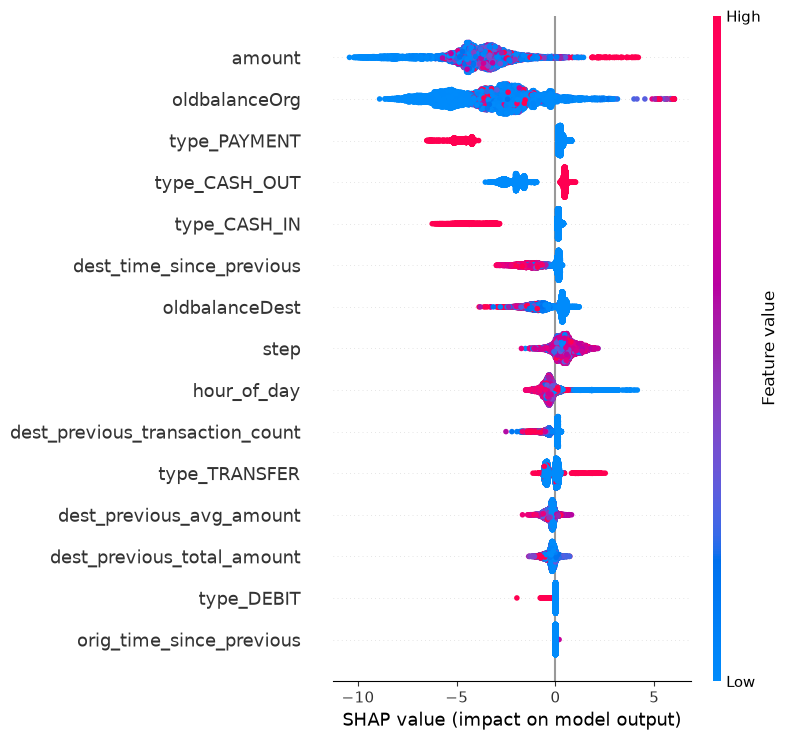

In [62]:
# ============================================================
# SHAP GLOBAL EXPLAINABILITY
# ============================================================

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import shap

print("Preparing SHAP analysis...")

# Sample the test set for efficient SHAP computation
sample_size = min(10_000, len(X_test))

X_shap = X_test.sample(
    n=sample_size,
    random_state=42
)

print(f"SHAP sample shape: {X_shap.shape}")

# Create SHAP explainer for XGBoost
explainer = shap.TreeExplainer(model)

# Calculate SHAP values
shap_values = explainer.shap_values(X_shap)

print("SHAP values calculated.")
print("Shape:", shap_values.shape)


# ============================================================
# GLOBAL FEATURE IMPORTANCE
# ============================================================

shap_importance = pd.DataFrame({
    "Feature": X_shap.columns,
    "Mean_Abs_SHAP": np.abs(shap_values).mean(axis=0)
})

shap_importance = (
    shap_importance
    .sort_values("Mean_Abs_SHAP", ascending=False)
    .reset_index(drop=True)
)

print("\n" + "=" * 70)
print("GLOBAL SHAP FEATURE IMPORTANCE")
print("=" * 70)

print(shap_importance.to_string(index=False))


# ============================================================
# SHAP SUMMARY PLOT
# ============================================================

plt.figure(figsize=(10, 8))

shap.summary_plot(
    shap_values,
    X_shap,
    max_display=15,
    show=False
)

plt.tight_layout()
plt.show()

TRANSACTION EXPLANATION

Transaction index: 6283804

Actual class:
1

Predicted fraud probability:
0.9999894

Transaction features:
amount                             2333929.91
dest_previous_avg_amount                 0.00
dest_previous_total_amount               0.00
dest_previous_transaction_count          0.00
dest_time_since_previous                -1.00
hour_of_day                              9.00
oldbalanceDest                           0.00
oldbalanceOrg                      2333929.91
orig_previous_avg_amount                 0.00
orig_previous_total_amount               0.00
orig_previous_transaction_count          0.00
orig_time_since_previous                -1.00
step                                   657.00
type_CASH_IN                             0.00
type_CASH_OUT                            0.00
type_DEBIT                               0.00
type_PAYMENT                             0.00
type_TRANSFER                            1.00
Name: 6283804, dtype: float64

TOP FEATU

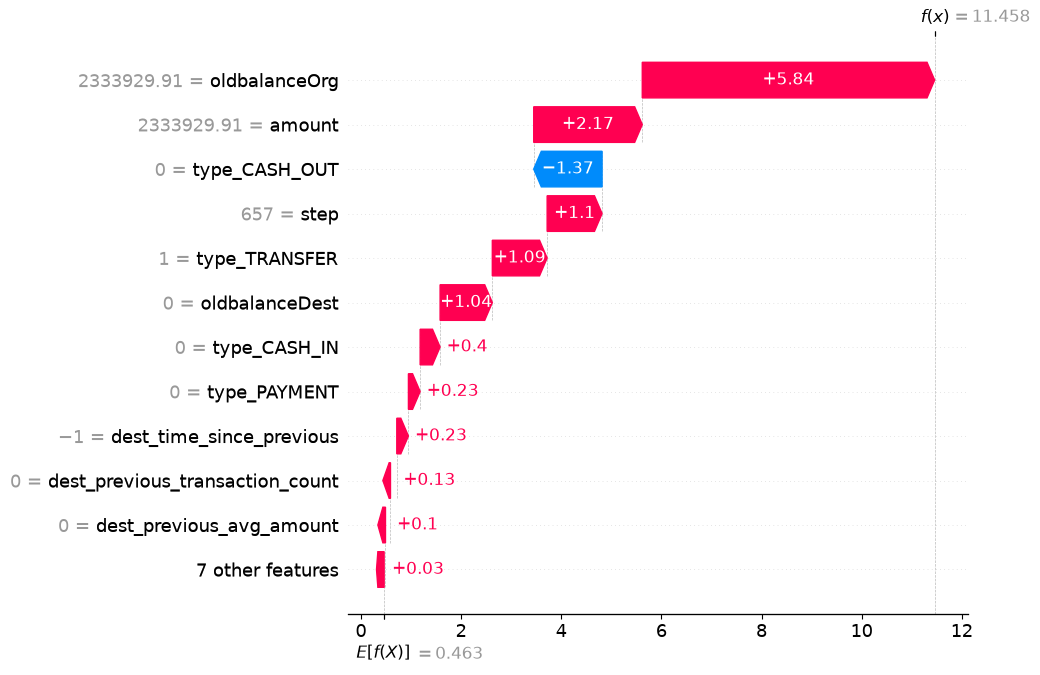

In [63]:
# ============================================================
# INDIVIDUAL FRAUD EXPLANATION
# ============================================================

# Find a fraudulent transaction in the SHAP sample
fraud_indices = X_shap.index[y_test.loc[X_shap.index] == 1]

# Select the first fraud transaction
fraud_idx = fraud_indices[0]

# Position of this transaction inside X_shap
fraud_position = X_shap.index.get_loc(fraud_idx)

print("=" * 70)
print("TRANSACTION EXPLANATION")
print("=" * 70)

print(f"\nTransaction index: {fraud_idx}")

print("\nActual class:")
print(y_test.loc[fraud_idx])

print("\nPredicted fraud probability:")
print(y_test_proba[X_test.index.get_loc(fraud_idx)])

print("\nTransaction features:")
print(
    X_test.loc[fraud_idx]
    .sort_index()
)


# ============================================================
# SHAP CONTRIBUTIONS
# ============================================================

transaction_shap = pd.DataFrame({
    "Feature": X_shap.columns,
    "Feature_Value": X_shap.iloc[fraud_position].values,
    "SHAP_Value": shap_values[fraud_position]
})

transaction_shap["Absolute_SHAP"] = (
    transaction_shap["SHAP_Value"].abs()
)

transaction_shap = (
    transaction_shap
    .sort_values("Absolute_SHAP", ascending=False)
    .reset_index(drop=True)
)

print("\n" + "=" * 70)
print("TOP FEATURES DRIVING THIS PREDICTION")
print("=" * 70)

print(
    transaction_shap.head(10).to_string(index=False)
)


# ============================================================
# WATERFALL PLOT
# ============================================================

shap.plots.waterfall(
    shap.Explanation(
        values=shap_values[fraud_position],
        base_values=explainer.expected_value,
        data=X_shap.iloc[fraud_position].values,
        feature_names=X_shap.columns
    ),
    max_display=12
)

In [64]:
# ============================================================
# TEMPORAL ROBUSTNESS CHECK
# ============================================================

test_results = X_test.copy()

test_results["actual"] = y_test
test_results["prediction"] = y_test_proba

# Create time buckets
test_results["time_bucket"] = pd.qcut(
    test_results["step"],
    q=5,
    duplicates="drop"
)

temporal_results = []

for bucket, group in test_results.groupby(
    "time_bucket",
    observed=True
):
    from sklearn.metrics import (
        average_precision_score,
        f1_score,
        precision_score,
        recall_score,
    )

    y_true = group["actual"]
    y_prob = group["prediction"]
    y_pred = (y_prob >= 0.05).astype(int)

    temporal_results.append({
        "Time Period": str(bucket),
        "Transactions": len(group),
        "Fraud": int(y_true.sum()),
        "Fraud Rate (%)": y_true.mean() * 100,
        "PR-AUC": average_precision_score(y_true, y_prob),
        "Precision": precision_score(
            y_true, y_pred, zero_division=0
        ),
        "Recall": recall_score(
            y_true, y_pred, zero_division=0
        ),
        "F1": f1_score(
            y_true, y_pred, zero_division=0
        )
    })

temporal_results = pd.DataFrame(temporal_results)

print("=" * 90)
print("TEMPORAL ROBUSTNESS CHECK")
print("=" * 90)

print(
    temporal_results.to_string(index=False)
)

TEMPORAL ROBUSTNESS CHECK
     Time Period  Transactions  Fraud  Fraud Rate (%)   PR-AUC  Precision   Recall       F1
(631.999, 661.0]         18057    344        1.905078 0.955269   0.365957 1.000000 0.535826
  (661.0, 686.0]         21731    250        1.150430 0.941700   0.247258 0.992000 0.395850
  (686.0, 688.0]         15925     16        0.100471 0.874592   0.028725 1.000000 0.055846
  (688.0, 692.0]         16693     58        0.347451 0.953698   0.091918 1.000000 0.168360
  (692.0, 743.0]         17060    584        3.423212 0.977710   0.469404 0.998288 0.638554


In [65]:
# ============================================================
# REAL-TIME FEATURE AVAILABILITY AUDIT
# ============================================================

feature_audit = {
    # Available when the transaction request arrives
    "step": "SAFE",
    "type": "SAFE",
    "amount": "SAFE",
    "oldbalanceOrg": "SAFE",
    "oldbalanceDest": "SAFE",

    # Calculated from the current transaction/balances
    "newbalanceOrig": "CURRENT_TRANSACTION",
    "newbalanceDest": "CURRENT_TRANSACTION",
    "orig_balance_change": "CURRENT_TRANSACTION",
    "dest_balance_change": "CURRENT_TRANSACTION",
    "orig_balance_error": "CURRENT_TRANSACTION",
    "dest_balance_error": "CURRENT_TRANSACTION",

    # Time-derived
    "hour_of_day": "SAFE",

    # Historical behavioral features
    "orig_previous_transaction_count": "HISTORICAL",
    "orig_previous_total_amount": "HISTORICAL",
    "orig_previous_avg_amount": "HISTORICAL",
    "dest_previous_transaction_count": "HISTORICAL",
    "dest_previous_total_amount": "HISTORICAL",
    "dest_previous_avg_amount": "HISTORICAL",
    "orig_time_since_previous": "HISTORICAL",
    "dest_time_since_previous": "HISTORICAL",

    # Ratios based on current transaction/balance information
    "amount_to_orig_balance": "CURRENT_TRANSACTION",
    "amount_to_dest_balance": "CURRENT_TRANSACTION",
    "orig_balance_change_ratio": "CURRENT_TRANSACTION",
    "dest_balance_change_ratio": "CURRENT_TRANSACTION",

    # Transaction type encoding
    "type_CASH_IN": "SAFE",
    "type_CASH_OUT": "SAFE",
    "type_DEBIT": "SAFE",
    "type_PAYMENT": "SAFE",
    "type_TRANSFER": "SAFE",
}

audit_df = pd.DataFrame(
    feature_audit.items(),
    columns=["Feature", "Availability"]
)

print("=" * 75)
print("REAL-TIME FEATURE AVAILABILITY AUDIT")
print("=" * 75)

print(audit_df.to_string(index=False))

print("\n" + "=" * 75)
print("SUMMARY")
print("=" * 75)

print(
    audit_df["Availability"]
    .value_counts()
    .to_string()
)

print("\n" + "=" * 75)
print("FEATURES BY CATEGORY")
print("=" * 75)

for category in audit_df["Availability"].unique():
    print(f"\n[{category}]")
    for feature in audit_df.loc[
        audit_df["Availability"] == category,
        "Feature"
    ]:
        print(f"  - {feature}")

REAL-TIME FEATURE AVAILABILITY AUDIT
                        Feature        Availability
                           step                SAFE
                           type                SAFE
                         amount                SAFE
                  oldbalanceOrg                SAFE
                 oldbalanceDest                SAFE
                 newbalanceOrig CURRENT_TRANSACTION
                 newbalanceDest CURRENT_TRANSACTION
            orig_balance_change CURRENT_TRANSACTION
            dest_balance_change CURRENT_TRANSACTION
             orig_balance_error CURRENT_TRANSACTION
             dest_balance_error CURRENT_TRANSACTION
                    hour_of_day                SAFE
orig_previous_transaction_count          HISTORICAL
     orig_previous_total_amount          HISTORICAL
       orig_previous_avg_amount          HISTORICAL
dest_previous_transaction_count          HISTORICAL
     dest_previous_total_amount          HISTORICAL
       dest_previous_avg_am

#  baseline threshold analysis and model artifact


In [66]:
thresholds = [0.01, 0.05, 0.10, 0.20, 0.30, 0.40, 0.50, 0.60, 0.70, 0.80, 0.90]

def threshold_analysis(y_true, probabilities, split_name):
    rows = []
    for threshold in thresholds:
        predictions = (probabilities >= threshold).astype(int)
        _, false_positives, false_negatives, _ = confusion_matrix(y_true, predictions).ravel()
        rows.append({
            "Threshold": threshold,
            "Precision": precision_score(y_true, predictions, zero_division=0),
            "Recall": recall_score(y_true, predictions, zero_division=0),
            "F1": f1_score(y_true, predictions, zero_division=0),
            "False Positives": false_positives,
            "False Negatives": false_negatives,
        })
    results = pd.DataFrame(rows)
    print(f"{split_name} THRESHOLD ANALYSIS")
    display(results)
    return results

validation_threshold_results = threshold_analysis(y_val, y_val_proba, "VALIDATION")
test_threshold_results = threshold_analysis(y_test, y_test_proba, "TEST")

VALIDATION THRESHOLD ANALYSIS


,Threshold,Precision,Recall,F1,False Positives,False Negatives
0,0.01,0.104038,1.000000,0.188468,10162,0
1,0.05,0.153276,0.999153,0.265780,6513,1
2,0.10,0.184392,0.999153,0.311328,5215,1
3,0.20,0.227290,0.996610,0.370161,3998,4
4,0.30,0.264474,0.994915,0.417868,3265,6
5,0.40,0.298880,0.994915,0.459671,2754,6
6,0.50,0.334093,0.994068,0.500107,2338,7
7,0.60,0.371819,0.990678,0.540703,1975,11
8,0.70,0.422045,0.986441,0.591163,1594,16
9,0.80,0.491497,0.979661,0.654587,1196,24


TEST THRESHOLD ANALYSIS


,Threshold,Precision,Recall,F1,False Positives,False Negatives
0,0.01,0.202528,0.998403,0.336746,4922,2
1,0.05,0.285616,0.997604,0.444089,3124,3
2,0.10,0.332533,0.996006,0.498601,2503,5
3,0.20,0.393853,0.992812,0.563975,1913,9
4,0.30,0.439137,0.991214,0.608632,1585,11
5,0.40,0.479627,0.987220,0.645599,1341,16
6,0.50,0.517677,0.982428,0.678060,1146,22
7,0.60,0.556767,0.979233,0.709902,976,26
8,0.70,0.600689,0.974441,0.743223,811,32
9,0.80,0.658804,0.959265,0.781138,622,51


In [67]:
from pathlib import Path

import xgboost as xgb

artifact_path = Path("../src/artifacts/fraud_model.json")
artifact_path.parent.mkdir(parents=True, exist_ok=True)
model.save_model(artifact_path)

loaded_model = xgb.XGBClassifier()
loaded_model.load_model(artifact_path)
reload_proba = loaded_model.predict_proba(X_test.head(5))[:, 1]
assert np.allclose(reload_proba, y_test_proba[:5])
print(f"Saved and verified model artifact: {artifact_path}")

Saved and verified model artifact: ../src/artifacts/fraud_model.json


In [68]:
from pathlib import Path

import pandas as pd

# Work on a copy so the notebook's main dataframe is not modified
fixture_source = df.copy()

# ---------------------------------------------------------
# 1. Build point-in-time historical features
# ---------------------------------------------------------

# Sort chronologically
fixture_source = fixture_source.sort_values("step").copy()

# Origin account history BEFORE the current transaction
fixture_source["orig_previous_transaction_count"] = (
    fixture_source.groupby("nameOrig").cumcount()
)

fixture_source["orig_previous_total_amount"] = (
    fixture_source.groupby("nameOrig")["amount"]
    .cumsum()
    .sub(fixture_source["amount"])
)

fixture_source["orig_previous_avg_amount"] = (
    fixture_source["orig_previous_total_amount"]
    / fixture_source["orig_previous_transaction_count"].replace(0, pd.NA)
).fillna(0.0)

# Destination account history BEFORE the current transaction
fixture_source["dest_previous_transaction_count"] = (
    fixture_source.groupby("nameDest").cumcount()
)

fixture_source["dest_previous_total_amount"] = (
    fixture_source.groupby("nameDest")["amount"]
    .cumsum()
    .sub(fixture_source["amount"])
)

fixture_source["dest_previous_avg_amount"] = (
    fixture_source["dest_previous_total_amount"]
    / fixture_source["dest_previous_transaction_count"].replace(0, pd.NA)
).fillna(0.0)

# ---------------------------------------------------------
# 2. Time since previous transaction
# ---------------------------------------------------------

fixture_source["orig_previous_step"] = (
    fixture_source.groupby("nameOrig")["step"].shift(1)
)

fixture_source["dest_previous_step"] = (
    fixture_source.groupby("nameDest")["step"].shift(1)
)

fixture_source["orig_time_since_previous"] = (
    fixture_source["step"] - fixture_source["orig_previous_step"]
).fillna(-1.0)

fixture_source["dest_time_since_previous"] = (
    fixture_source["step"] - fixture_source["dest_previous_step"]
).fillna(-1.0)

# ---------------------------------------------------------
# 3. Restrict to the held-out test period
# ---------------------------------------------------------

test_df = fixture_source[
    fixture_source["step"] > 631
].copy()

# ---------------------------------------------------------
# 4. Select real examples
# ---------------------------------------------------------

fraud_examples = (
    test_df[test_df["isFraud"] == 1]
    .sample(n=10, random_state=42)
)

legitimate_examples = (
    test_df[test_df["isFraud"] == 0]
    .sample(n=10, random_state=42)
)

fixture_df = (
    pd.concat(
        [fraud_examples, legitimate_examples],
        ignore_index=True,
    )
    .sample(frac=1, random_state=42)
    .reset_index(drop=True)
)

# ---------------------------------------------------------
# 5. Keep exactly the production inference fields
# ---------------------------------------------------------

fixture_features = [
    "step",
    "type",
    "amount",
    "oldbalanceOrg",
    "oldbalanceDest",
    "orig_previous_transaction_count",
    "orig_previous_total_amount",
    "orig_time_since_previous",
    "dest_previous_transaction_count",
    "dest_previous_total_amount",
    "dest_time_since_previous",
]

fixture_df = fixture_df[
    fixture_features + ["isFraud"]
]

# ---------------------------------------------------------
# 6. Save fixture
# ---------------------------------------------------------

fixture_path = Path("../src/tests/fixtures/fraud_examples.csv")
fixture_path.parent.mkdir(parents=True, exist_ok=True)

fixture_df.to_csv(
    fixture_path,
    index=False,
)

# ---------------------------------------------------------
# 7. Verify
# ---------------------------------------------------------

print(f"Saved {len(fixture_df)} examples to:")
print(fixture_path.resolve())

print("\nClass distribution:")
print(fixture_df["isFraud"].value_counts())

print("\nFixture:")
display(fixture_df)

Saved 20 examples to:
/home/dawit-abraham/projects/ai/fraud_detection_ml/src/tests/fixtures/fraud_examples.csv

Class distribution:
isFraud
1    10
0    10
Name: count, dtype: int64

Fixture:


,step,type,amount,oldbalanceOrg,oldbalanceDest,orig_previous_transaction_count,orig_previous_total_amount,orig_time_since_previous,dest_previous_transaction_count,dest_previous_total_amount,dest_time_since_previous,isFraud
0,697,CASH_OUT,378623.90,378623.90,0.00,0,0.0,-1.0,0,0.00,-1.0,1
1,691,PAYMENT,3058.88,20025.00,0.00,0,0.0,-1.0,0,0.00,-1.0,0
2,659,TRANSFER,818015.67,0.00,1621416.48,0,0.0,-1.0,9,2855383.46,109.0,0
3,742,CASH_OUT,303846.74,303846.74,343660.89,0,0.0,-1.0,1,270531.85,54.0,1
4,695,CASH_OUT,286835.21,286835.21,1678767.02,0,0.0,-1.0,22,4282261.90,293.0,1
5,741,TRANSFER,62297.18,62297.18,0.00,0,0.0,-1.0,0,0.00,-1.0,1
6,637,CASH_OUT,346565.23,22150.00,0.00,0,0.0,-1.0,0,0.00,-1.0,0
7,714,CASH_OUT,8838.19,8838.19,15334.27,0,0.0,-1.0,0,0.00,-1.0,1
8,661,CASH_IN,445696.33,145429.00,355472.07,0,0.0,-1.0,3,428696.79,305.0,0
9,644,CASH_IN,51221.83,5029.00,8797016.72,0,0.0,-1.0,30,12532051.42,241.0,0


In [69]:
import numpy as np
import pandas as pd
from sklearn.metrics import (
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
)

threshold_results = []

thresholds = np.arange(0.05, 1.00, 0.05)

for threshold in thresholds:
    y_pred = (y_test_proba >= threshold).astype(int)

    tn, fp, fn, tp = confusion_matrix(
        y_test,
        y_pred,
    ).ravel()

    precision = precision_score(
        y_test,
        y_pred,
        zero_division=0,
    )

    recall = recall_score(
        y_test,
        y_pred,
        zero_division=0,
    )

    f1 = f1_score(
        y_test,
        y_pred,
        zero_division=0,
    )

    false_positive_rate = fp / (fp + tn)

    threshold_results.append({
        "threshold": threshold,
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "false_positive_rate": false_positive_rate,
        "false_positives": fp,
        "false_negatives": fn,
        "true_positives": tp,
        "true_negatives": tn,
    })

threshold_df = pd.DataFrame(threshold_results)

threshold_df.sort_values(
    "f1",
    ascending=False,
).reset_index(drop=True)

,threshold,precision,recall,f1,false_positive_rate,false_positives,false_negatives,true_positives,true_negatives
0,0.95,0.824945,0.903355,0.862371,0.002721,240,121,1131,87974
1,0.90,0.750481,0.934505,0.832444,0.004410,389,82,1170,87825
2,0.85,0.699941,0.952077,0.806768,0.005793,511,60,1192,87703
3,0.80,0.658804,0.959265,0.781138,0.007051,622,51,1201,87592
4,0.75,0.629342,0.969649,0.763282,0.008105,715,38,1214,87499
5,0.70,0.600689,0.974441,0.743223,0.009194,811,32,1220,87403
6,0.65,0.579346,0.976837,0.727327,0.010066,888,29,1223,87326
7,0.60,0.556767,0.979233,0.709902,0.011064,976,26,1226,87238
8,0.55,0.540255,0.980831,0.696738,0.011846,1045,24,1228,87169
9,0.50,0.517677,0.982428,0.678060,0.012991,1146,22,1230,87068


In [70]:
print(
    threshold_df.sort_values(
        "f1",
        ascending=False,
    ).head(10).to_string(index=False)
)

 threshold  precision   recall       f1  false_positive_rate  false_positives  false_negatives  true_positives  true_negatives
      0.95   0.824945 0.903355 0.862371             0.002721              240              121            1131           87974
      0.90   0.750481 0.934505 0.832444             0.004410              389               82            1170           87825
      0.85   0.699941 0.952077 0.806768             0.005793              511               60            1192           87703
      0.80   0.658804 0.959265 0.781138             0.007051              622               51            1201           87592
      0.75   0.629342 0.969649 0.763282             0.008105              715               38            1214           87499
      0.70   0.600689 0.974441 0.743223             0.009194              811               32            1220           87403
      0.65   0.579346 0.976837 0.727327             0.010066              888               29            1223 

In [71]:
print(
    threshold_df.sort_values(
        "precision",
        ascending=False,
    ).head(10).to_string(index=False)
)

 threshold  precision   recall       f1  false_positive_rate  false_positives  false_negatives  true_positives  true_negatives
      0.95   0.824945 0.903355 0.862371             0.002721              240              121            1131           87974
      0.90   0.750481 0.934505 0.832444             0.004410              389               82            1170           87825
      0.85   0.699941 0.952077 0.806768             0.005793              511               60            1192           87703
      0.80   0.658804 0.959265 0.781138             0.007051              622               51            1201           87592
      0.75   0.629342 0.969649 0.763282             0.008105              715               38            1214           87499
      0.70   0.600689 0.974441 0.743223             0.009194              811               32            1220           87403
      0.65   0.579346 0.976837 0.727327             0.010066              888               29            1223 

In [72]:
target_recalls = [0.90, 0.95, 0.97, 0.98]

for target in target_recalls:
    candidates = threshold_df[
        threshold_df["recall"] >= target
    ].sort_values("precision", ascending=False)

    print(f"\nTarget recall >= {target:.0%}")

    if candidates.empty:
        print("No threshold meets this target.")
        continue

    print(
        candidates.iloc[0][
            [
                "threshold",
                "precision",
                "recall",
                "f1",
                "false_positives",
                "false_negatives",
            ]
        ]
    )


Target recall >= 90%
threshold            0.950000
precision            0.824945
recall               0.903355
f1                   0.862371
false_positives    240.000000
false_negatives    121.000000
Name: 18, dtype: float64

Target recall >= 95%
threshold            0.850000
precision            0.699941
recall               0.952077
f1                   0.806768
false_positives    511.000000
false_negatives     60.000000
Name: 16, dtype: float64

Target recall >= 97%
threshold            0.700000
precision            0.600689
recall               0.974441
f1                   0.743223
false_positives    811.000000
false_negatives     32.000000
Name: 13, dtype: float64

Target recall >= 98%
threshold             0.550000
precision             0.540255
recall                0.980831
f1                    0.696738
false_positives    1045.000000
false_negatives      24.000000
Name: 10, dtype: float64


In [73]:
validation_threshold_results = []

thresholds = np.arange(0.05, 1.00, 0.01)

for threshold in thresholds:
    y_pred = (y_val_proba >= threshold).astype(int)

    tn, fp, fn, tp = confusion_matrix(
        y_val,
        y_pred,
    ).ravel()

    precision = precision_score(
        y_val,
        y_pred,
        zero_division=0,
    )

    recall = recall_score(
        y_val,
        y_pred,
        zero_division=0,
    )

    f1 = f1_score(
        y_val,
        y_pred,
        zero_division=0,
    )

    false_positive_rate = fp / (fp + tn)

    validation_threshold_results.append({
        "threshold": threshold,
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "false_positive_rate": false_positive_rate,
        "false_positives": fp,
        "false_negatives": fn,
        "true_positives": tp,
        "true_negatives": tn,
    })

validation_threshold_df = pd.DataFrame(
    validation_threshold_results
)

In [74]:
validation_threshold_df[
    validation_threshold_df["recall"] >= 0.95
].sort_values(
    "precision",
    ascending=False,
).head(10)

,threshold,precision,recall,f1,false_positive_rate,false_positives,false_negatives,true_positives,true_negatives
87,0.92,0.643144,0.950000,0.767020,0.003274,622,59,1121,189345
86,0.91,0.623269,0.953390,0.753769,0.003580,680,55,1125,189287
85,0.90,0.607085,0.958475,0.743345,0.003853,732,49,1131,189235
84,0.89,0.590933,0.961017,0.731849,0.004132,785,46,1134,189182
83,0.88,0.574962,0.965254,0.720658,0.004432,842,41,1139,189125
82,0.87,0.563332,0.968644,0.712371,0.004664,886,37,1143,189081
81,0.86,0.553891,0.971186,0.705448,0.004859,923,34,1146,189044
80,0.85,0.543344,0.972034,0.697053,0.005075,964,33,1147,189003
79,0.84,0.530990,0.972881,0.687014,0.005338,1014,32,1148,188953
78,0.83,0.520163,0.972881,0.677886,0.005575,1059,32,1148,188908


In [75]:
validation_threshold_df.sort_values(
    "f1",
    ascending=False,
).head(10)

,threshold,precision,recall,f1,false_positive_rate,false_positives,false_negatives,true_positives,true_negatives
94,0.99,0.921245,0.852542,0.885563,0.000453,86,174,1006,189881
93,0.98,0.873640,0.884746,0.879158,0.000795,151,136,1044,189816
92,0.97,0.815830,0.908475,0.859663,0.001274,242,108,1072,189725
91,0.96,0.767769,0.924576,0.838908,0.001737,330,89,1091,189637
90,0.95,0.727093,0.934746,0.817946,0.002179,414,77,1103,189553
89,0.94,0.697982,0.938136,0.800434,0.002521,479,73,1107,189488
88,0.93,0.671084,0.944068,0.784507,0.002874,546,66,1114,189421
87,0.92,0.643144,0.950000,0.767020,0.003274,622,59,1121,189345
86,0.91,0.623269,0.953390,0.753769,0.003580,680,55,1125,189287
85,0.90,0.607085,0.958475,0.743345,0.003853,732,49,1131,189235


In [76]:
selected_threshold = 0.92

y_test_pred = (
    y_test_proba >= selected_threshold
).astype(int)

tn, fp, fn, tp = confusion_matrix(
    y_test,
    y_test_pred,
).ravel()

test_precision = precision_score(
    y_test,
    y_test_pred,
    zero_division=0,
)

test_recall = recall_score(
    y_test,
    y_test_pred,
    zero_division=0,
)

test_f1 = f1_score(
    y_test,
    y_test_pred,
    zero_division=0,
)

test_fpr = fp / (fp + tn)

print(f"Threshold:       {selected_threshold:.2f}")
print(f"Precision:       {test_precision:.4f}")
print(f"Recall:          {test_recall:.4f}")
print(f"F1:              {test_f1:.4f}")
print(f"False positive rate: {test_fpr:.6f}")
print(f"False positives: {fp}")
print(f"False negatives: {fn}")
print(f"True positives:  {tp}")
print(f"True negatives:  {tn}")

Threshold:       0.92
Precision:       0.7852
Recall:          0.9257
F1:              0.8497
False positive rate: 0.003594
False positives: 317
False negatives: 93
True positives:  1159
True negatives:  87897
